In [1]:
import pandas as pd
import numpy as np
from gensim.models import Word2Vec, FastText
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from collections import Counter

/Users/isaac/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
from Data.Tool import *
from Model.Tool import *
from Model.model import *

df_train = parser_donnees_presidents('Data/train/corpus.tache1.learn.utf8')
df_train['Texte_Nettoye'] = df_train['Texte'].apply(nettoyer_texte)
X = df_train['Texte']
y = pd.Series(df_train['Cible_Chirac'])

--- Statistiques des longueurs de phrases ---
count    57413.000000
mean        11.604236
std          7.696624
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        210.000000
Name: Texte_Nettoye, dtype: float64
90% des phrases ont moins de : 21 mots
95% des phrases ont moins de : 26 mots
99% des phrases ont moins de : 38 mots


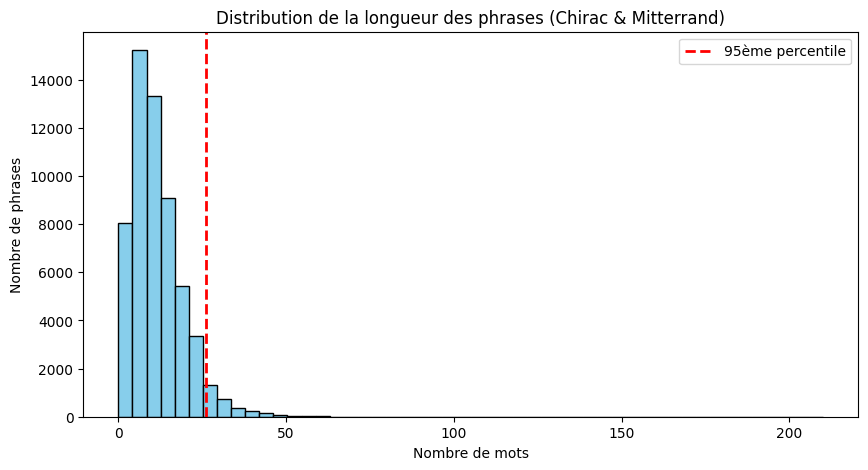


--- Statistiques du vocabulaire ---
Nombre total de mots uniques : 28038
Mots apparaissant plus de 2 fois : 13960


In [32]:
# --- ANALYSE DE LA LONGUEUR DES PHRASES (MAX_LEN) ---
# On compte le nombre de mots par phrase
longueurs = df_train['Texte_Nettoye'].apply(lambda x: len(str(x).split()))

print("--- Statistiques des longueurs de phrases ---")
print(longueurs.describe())
print(f"90% des phrases ont moins de : {np.percentile(longueurs, 90):.0f} mots")
print(f"95% des phrases ont moins de : {np.percentile(longueurs, 95):.0f} mots")
print(f"99% des phrases ont moins de : {np.percentile(longueurs, 99):.0f} mots")

# Graphique pour ton rapport
plt.figure(figsize=(10, 5))
plt.hist(longueurs, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution de la longueur des phrases (Chirac & Mitterrand)')
plt.xlabel('Nombre de mots')
plt.ylabel('Nombre de phrases')
plt.axvline(np.percentile(longueurs, 95), color='red', linestyle='dashed', linewidth=2, label='95ème percentile')
plt.legend()
plt.show()

# --- ANALYSE DU VOCABULAIRE (MAX_WORDS) ---
tous_les_mots = " ".join(df_train['Texte_Nettoye'].astype(str)).split()
compteur_mots = Counter(tous_les_mots)

mots_uniques = len(compteur_mots)
mots_freq_sup_2 = len([mot for mot, freq in compteur_mots.items() if freq > 2])

print("\n--- Statistiques du vocabulaire ---")
print(f"Nombre total de mots uniques : {mots_uniques}")
print(f"Mots apparaissant plus de 2 fois : {mots_freq_sup_2}")

In [3]:
def train_embedders(tokenized_texts, size=300):
    print("⏳ Entraînement Word2Vec...")
    w2v = Word2Vec(sentences=tokenized_texts, vector_size=size, window=5, min_count=2, workers=4)
    
    print("⏳ Entraînement FastText...")
    ft = FastText(sentences=tokenized_texts, vector_size=size, window=5, min_count=2, workers=4)
    
    return w2v, ft

In [ ]:
X_tokenized = X.apply(lambda x: str(x).split())
X_train_tfidf, X_val_tfidf, tfidf = transform_tfidf(df_train['Texte_Nettoye'],)

⏳ Vectorisation TF-IDF (max_features=5000)...


In [12]:
X_vectors.shape

(300, 5000)

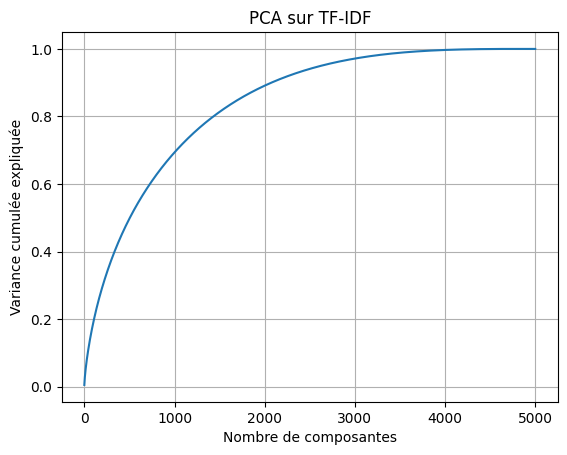

Dimensions nécessaires pour 95% de variance : 2624


In [16]:
X_vectors =  X_train_tfidf.toarray()[:6000]

# --- PCA ---
pca = PCA()
pca.fit(X_vectors)

# Variance expliquée cumulée
explained_variance = np.cumsum(pca.explained_variance_ratio_)

# --- Affichage ---
plt.plot(explained_variance)
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance cumulée expliquée")
plt.title("PCA sur TF-IDF")
plt.grid(True)
plt.show()

# Combien de dimensions pour 95% de variance
n_components_95 = np.argmax(explained_variance >= 0.95) + 1
print("Dimensions nécessaires pour 95% de variance :", n_components_95)


⏳ Entraînement Word2Vec...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


⏳ Entraînement FastText...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


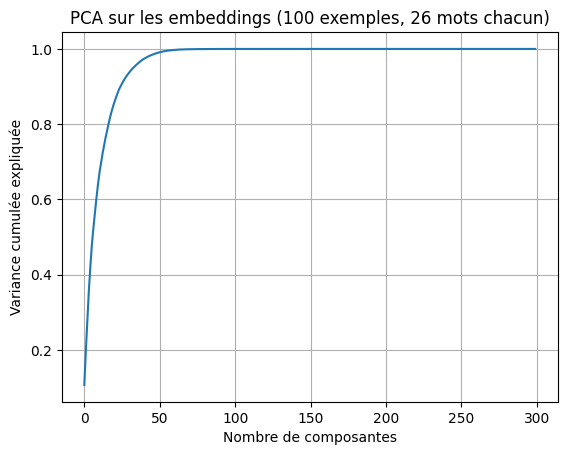

Dimensions nécessaires pour 95% de variance : 34
Dimensions nécessaires pour 99% de variance : 50


In [ ]:
EMB_SIZE=300
# --- Utilisation ---
w2v, ft = train_embedders(X_tokenized,size=EMB_SIZE)
X_train_seq = texts_to_sequences(X_tokenized , w2v, max_len=26,vector_size=EMB_SIZE)
# --- Sélectionner 100 exemples ---
X_sample = X_train_seq[:100]  # shape (100, 26, 300)

# --- Combiner tous les vecteurs dans un seul tableau ---
# on aura 100*26 vecteurs de dimension 300
X_vectors = X_sample.reshape(-1, X_sample.shape[2])  # shape (100*26, 300)

# --- PCA ---
pca = PCA()
pca.fit(X_vectors)

# Variance expliquée cumulée
explained_variance = np.cumsum(pca.explained_variance_ratio_)

# --- Affichage ---
plt.plot(explained_variance)
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance cumulée expliquée")
plt.title("PCA sur les embeddings (100 exemples, 26 mots chacun)")
plt.grid(True)
plt.show()

# Combien de dimensions pour 95% de variance
n_components_95 = np.argmax(explained_variance >= 0.95) + 1
print("Dimensions nécessaires pour 95% de variance :", n_components_95)
n_components_99 = np.argmax(explained_variance >= 0.99) + 1
print("Dimensions nécessaires pour 99% de variance :", n_components_99)


⏳ Entraînement Word2Vec...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


⏳ Entraînement FastText...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


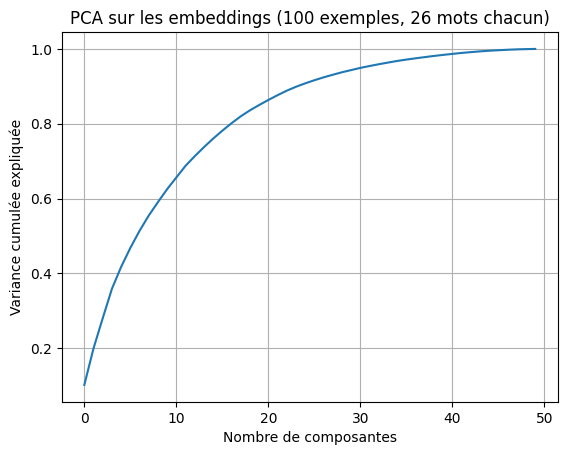

Dimensions nécessaires pour 95% de variance : 32


In [ ]:
EMB_SIZE=50
# --- Utilisation ---
w2v, ft = train_embedders(X_tokenized,size=EMB_SIZE)
X_train_seq = texts_to_sequences(X_tokenized , w2v, max_len=26,vector_size=EMB_SIZE)
# --- Sélectionner 100 exemples ---
X_sample = X_train_seq[:1000]  # shape (100, 26, 300)

# --- Combiner tous les vecteurs dans un seul tableau ---
# on aura 100*26 vecteurs de dimension 300
X_vectors = X_sample.reshape(-1, X_sample.shape[2])  # shape (100*26, 300)

# --- PCA ---
pca = PCA()
pca.fit(X_vectors)

# Variance expliquée cumulée
explained_variance = np.cumsum(pca.explained_variance_ratio_)

# --- Affichage ---
plt.plot(explained_variance)
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance cumulée expliquée")
plt.title("PCA sur les embeddings (100 exemples, 26 mots chacun)")
plt.grid(True)
plt.show()

# Combien de dimensions pour 95% de variance
n_components_95 = np.argmax(explained_variance >= 0.95) + 1
print("Dimensions nécessaires pour 95% de variance :", n_components_95)


⏳ Entraînement Word2Vec...
⏳ Entraînement FastText...


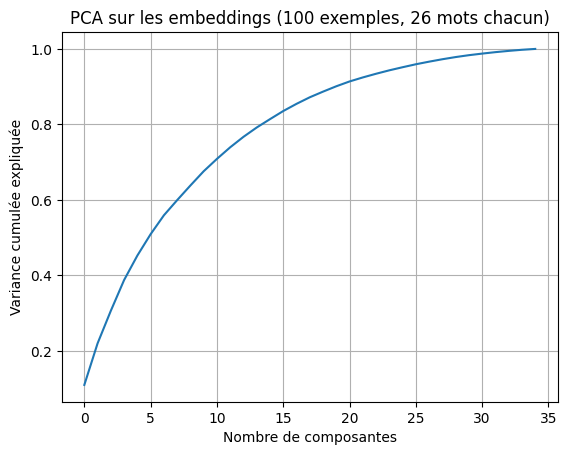

Dimensions nécessaires pour 95% de variance : 25


In [18]:
EMB_SIZE=35
# --- Utilisation ---
w2v, ft = train_embedders(X_tokenized,size=EMB_SIZE)
X_train_seq = texts_to_sequences(X_tokenized , w2v, max_len=26,vector_size=EMB_SIZE)
# --- Sélectionner 100 exemples ---
X_sample = X_train_seq[:1000]  # shape (100, 26, 300)

# --- Combiner tous les vecteurs dans un seul tableau ---
# on aura 100*26 vecteurs de dimension 300
X_vectors = X_sample.reshape(-1, X_sample.shape[2])  # shape (100*26, 300)

# --- PCA ---
pca = PCA()
pca.fit(X_vectors)

# Variance expliquée cumulée
explained_variance = np.cumsum(pca.explained_variance_ratio_)

# --- Affichage ---
plt.plot(explained_variance)
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance cumulée expliquée")
plt.title("PCA sur les embeddings (100 exemples, 26 mots chacun)")
plt.grid(True)
plt.show()

# Combien de dimensions pour 95% de variance
n_components_95 = np.argmax(explained_variance >= 0.95) + 1
print("Dimensions nécessaires pour 95% de variance :", n_components_95)
